In [1]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import DataLoader, TensorDataset
from sklearn.linear_model import Ridge
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xgboost as xgb
import torch.nn as nn
import torch
import joblib
import torch

In [2]:
# device check
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


In [3]:
# Load engineered data and preprocessor
merged_df = pd.read_parquet('../data/processed/merged_engineered.parquet')
preprocessor_new = joblib.load('../models/preprocessor_engineered.pkl')

# Features and targets
num_features_new = ['budget_tmdb', 'runtime_tmdb', 'popularity_tmdb', 'vote_count_tmdb', 'user_rating_count', 'num_genres', 'num_cast', 'num_crew', 
                    'release_year', 'cast_popularity', 'keyword_count', 'pos_keyword_ratio', 'director_score', 'overview_length']
cat_features = ['primary_genre', 'original_language_tmdb', 'release_season', 'adult_tmdb']

X_new = merged_df[num_features_new + cat_features]
y_revenue = merged_df['log_revenue']
y_rating = merged_df['avg_user_rating']

# Preprocess full X
X_proc = preprocessor_new.transform(X_new)
feature_names = preprocessor_new.get_feature_names_out()

print(f"Processed X Shape: {X_proc.shape}")

Processed X Shape: (5950, 70)


In [ ]:
# Setup KFold (k=5)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Models
linear = Ridge(alpha=1.0)  # Regularized Linear
rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

# Tuned XGBoost Params (from Week 4)
tuned_params = {'subsample': 0.8, 'n_estimators': 1000, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0, 'colsample_bytree': 0.6}

xgb_rev = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **tuned_params)
xgb_rat = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, **tuned_params)

# CV for Revenue (Ridge replaces Linear)
cv_r2_rev_ridge = cross_val_score(linear, X_proc, y_revenue, cv=kf, scoring='r2')
cv_rmse_rev_ridge = np.sqrt(-cross_val_score(linear, X_proc, y_revenue, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rev_ridge = -cross_val_score(linear, X_proc, y_revenue, cv=kf, scoring='neg_mean_absolute_error')

cv_r2_rev_rf = cross_val_score(rf, X_proc, y_revenue, cv=kf, scoring='r2')
cv_rmse_rev_rf = np.sqrt(-cross_val_score(rf, X_proc, y_revenue, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rev_rf = -cross_val_score(rf, X_proc, y_revenue, cv=kf, scoring='neg_mean_absolute_error')

cv_r2_rev_xgb = cross_val_score(xgb_rev, X_proc, y_revenue, cv=kf, scoring='r2')
cv_rmse_rev_xgb = np.sqrt(-cross_val_score(xgb_rev, X_proc, y_revenue, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rev_xgb = -cross_val_score(xgb_rev, X_proc, y_revenue, cv=kf, scoring='neg_mean_absolute_error')

# CV for Ratings
cv_r2_rat_linear = cross_val_score(linear, X_proc, y_rating, cv=kf, scoring='r2')
cv_rmse_rat_linear = np.sqrt(-cross_val_score(linear, X_proc, y_rating, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rat_linear = -cross_val_score(linear, X_proc, y_rating, cv=kf, scoring='neg_mean_absolute_error')

cv_r2_rat_rf = cross_val_score(rf, X_proc, y_rating, cv=kf, scoring='r2')
cv_rmse_rat_rf = np.sqrt(-cross_val_score(rf, X_proc, y_rating, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rat_rf = -cross_val_score(rf, X_proc, y_rating, cv=kf, scoring='neg_mean_absolute_error')

cv_r2_rat_xgb = cross_val_score(xgb_rat, X_proc, y_rating, cv=kf, scoring='r2')
cv_rmse_rat_xgb = np.sqrt(-cross_val_score(xgb_rat, X_proc, y_rating, cv=kf, scoring='neg_mean_squared_error'))
cv_mae_rat_xgb = -cross_val_score(xgb_rat, X_proc, y_rating, cv=kf, scoring='neg_mean_absolute_error')

# Print Averages/Std
print("Revenue CV Results")
print(f"Linear R2: {cv_r2_rev_ridge.mean():.4f} +- {cv_r2_rev_ridge.std():.4f}")
print(f"RF R2: {cv_r2_rev_rf.mean():.4f} +- {cv_r2_rev_rf.std():.4f}")
print(f"XGBoost R2: {cv_r2_rev_xgb.mean():.4f} +- {cv_r2_rev_xgb.std():.4f}")

print("\nRatings CV Results")
print(f"Linear R2: {cv_r2_rat_linear.mean():.4f} +- {cv_r2_rat_linear.std():.4f}")
print(f"RF R2: {cv_r2_rat_rf.mean():.4f} +- {cv_r2_rat_rf.std():.4f}")
print(f"XGBoost R2: {cv_r2_rat_xgb.mean():.4f} +- {cv_r2_rat_xgb.std():.4f}")

Revenue CV Results
Linear R2: 0.4395 +- 0.0148
RF R2: 0.6284 +- 0.0213
XGBoost R2: 0.6559 +- 0.0113

Ratings CV Results
Linear R2: 0.3989 +- 0.0129
RF R2: 0.5575 +- 0.0091
XGBoost R2: 0.6095 +- 0.0058


In [ ]:
# Set up device
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Redefine models
class MovieSuccessNN(nn.Module):
    def __init__(self, input_size: int, hidden_sizes: list[int] = [128, 64], dropout: float = 0.2):
        super(MovieSuccessNN, self).__init__()
        layers = []
        prev_size = input_size
        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_size = hidden
        layers.append(nn.Linear(prev_size, 1))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)

# Training function
def train_nn_fold(X_fold, y_fold, epochs: int = 1000, lr: float = 0.0001, batch_size: int = 64) -> MovieSuccessNN:
    model = MovieSuccessNN(X_fold.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    
    # Create Tensors
    X_tensor = torch.tensor(X_fold, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_fold.values, dtype=torch.float32).view(-1, 1).to(device)
    
    # Loader
    train_loader = DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=True)
    
    # Training Loop
    model.train()
    for epoch in range(epochs):
        for X_b, y_b in train_loader:
            optimizer.zero_grad()
            out = model(X_b)
            loss = criterion(out, y_b)
            loss.backward()
            optimizer.step()
    return model

# Cross val loop
kf = KFold(n_splits=5, shuffle=True, random_state=42)

Using device: mps


In [9]:
# Revenue CV

cv_r2_rev = []
cv_rmse_rev = []
cv_mae_rev = []
fold_count = 1

for train_idx, val_idx in kf.split(X_proc): 
    # Select Fold Data from X_proc
    X_train_fold, X_val_fold = X_proc[train_idx], X_proc[val_idx]
    
    # Select Fold Data from y_revenue
    y_train_fold, y_val_fold = y_revenue.iloc[train_idx], y_revenue.iloc[val_idx]
    
    # Train
    model = train_nn_fold(X_train_fold, y_train_fold, epochs=1000, lr=0.0001)
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32).to(device)
        y_pred = model(X_val_tensor).cpu().numpy()
    
    # Metrics
    r2 = r2_score(y_val_fold, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
    mae = mean_absolute_error(y_val_fold, y_pred)
    
    cv_r2_rev.append(r2)
    cv_rmse_rev.append(rmse)
    cv_mae_rev.append(mae)
    
    print(f"Fold {fold_count} Complete. R2: {r2:.4f}")
    fold_count += 1

print("\nRevenue NN CV Results")
print(f"R2:   {np.mean(cv_r2_rev):.4f} +- {np.std(cv_r2_rev):.4f}")
print(f"RMSE: {np.mean(cv_rmse_rev):.4f} +- {np.std(cv_rmse_rev):.4f}")
print(f"MAE:  {np.mean(cv_mae_rev):.4f} +- {np.std(cv_mae_rev):.4f}")

Fold 1 Complete. R2: 0.5728
Fold 2 Complete. R2: 0.5665
Fold 3 Complete. R2: 0.5982
Fold 4 Complete. R2: 0.6086
Fold 5 Complete. R2: 0.5784

Revenue NN CV Results
R2:   0.5849 +- 0.0159
RMSE: 1.2931 +- 0.0568
MAE:  0.9013 +- 0.0089


In [10]:
# Ratings CV

cv_r2_rat = []
cv_rmse_rat = []
cv_mae_rat = []
fold_count = 1

for train_idx, val_idx in kf.split(X_proc): 
    X_train_fold, X_val_fold = X_proc[train_idx], X_proc[val_idx]
    y_train_fold, y_val_fold = y_rating.iloc[train_idx], y_rating.iloc[val_idx]
    
    # Train
    model = train_nn_fold(X_train_fold, y_train_fold, epochs=1000, lr=0.0001)
    
    # Evaluate
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32).to(device)
        y_pred = model(X_val_tensor).cpu().numpy()
    
    r2 = r2_score(y_val_fold, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
    mae = mean_absolute_error(y_val_fold, y_pred)
    
    cv_r2_rat.append(r2)
    cv_rmse_rat.append(rmse)
    cv_mae_rat.append(mae)
    
    print(f"Fold {fold_count}/5 Complete. R2: {r2:.4f}")
    fold_count += 1

print("\nRatings NN CV Results")
print(f"R2:   {np.mean(cv_r2_rat):.4f} +- {np.std(cv_r2_rat):.4f}")
print(f"RMSE: {np.mean(cv_rmse_rat):.4f} +- {np.std(cv_rmse_rat):.4f}")
print(f"MAE:  {np.mean(cv_mae_rat):.4f} +- {np.std(cv_mae_rat):.4f}")

Fold 1/5 Complete. R2: 0.5470
Fold 2/5 Complete. R2: 0.5468
Fold 3/5 Complete. R2: 0.5786
Fold 4/5 Complete. R2: 0.5840
Fold 5/5 Complete. R2: 0.5878

Ratings NN CV Results
R2:   0.5688 +- 0.0182
RMSE: 0.3279 +- 0.0076
MAE:  0.2466 +- 0.0048


K-Fold CV Comparison
     Model  Revenue R-squared Mean  Revenue R-squared Std  \
0   Linear                  0.4395                 0.0148   
1       RF                  0.6284                 0.0213   
2  XGBoost                  0.6559                 0.0113   
3       NN                  0.5849                 0.0159   

   Ratings R-squared Mean  Ratings R-squared Std  
0                  0.3989                 0.0129  
1                  0.5575                 0.0091  
2                  0.6095                 0.0058  
3                  0.5688                 0.0182  


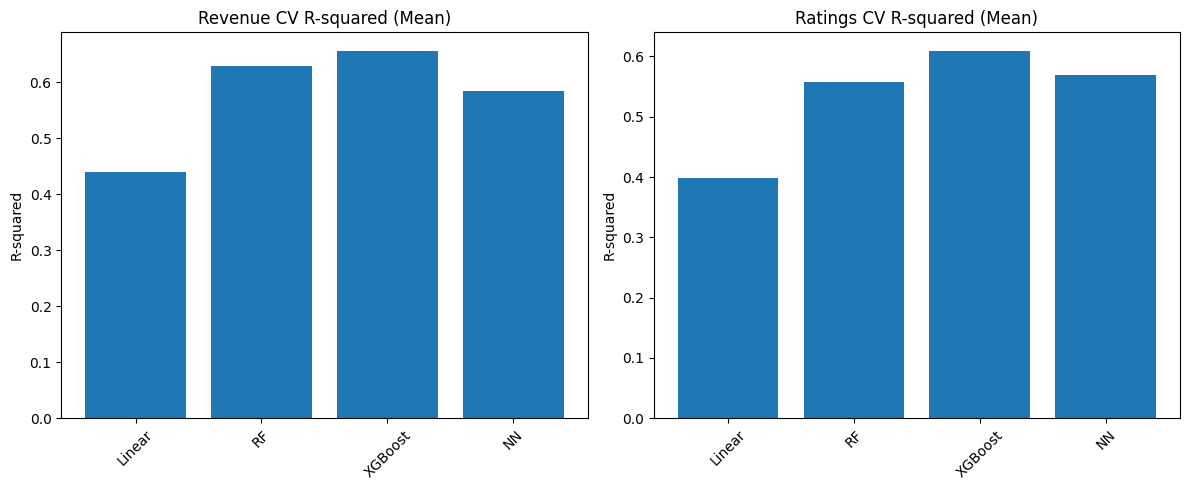

In [13]:
# Full CV Comparison Table
cv_comparison = pd.DataFrame({
    'Model': ['Linear', 'RF', 'XGBoost', 'NN'],
    
    'Revenue R-squared Mean': [cv_r2_rev_ridge.mean(), cv_r2_rev_rf.mean(), cv_r2_rev_xgb.mean(), np.mean(cv_r2_rev)],
    'Revenue R-squared Std': [cv_r2_rev_ridge.std(), cv_r2_rev_rf.std(), cv_r2_rev_xgb.std(), np.std(cv_r2_rev)],
    
    'Ratings R-squared Mean': [cv_r2_rat_linear.mean(), cv_r2_rat_rf.mean(), cv_r2_rat_xgb.mean(), np.mean(cv_r2_rat)],
    'Ratings R-squared Std': [cv_r2_rat_linear.std(), cv_r2_rat_rf.std(), cv_r2_rat_xgb.std(), np.std(cv_r2_rat)]
})
print("K-Fold CV Comparison")
print(cv_comparison.round(4))
cv_comparison.to_csv('../reports/cv_comparison.csv', index=False)

# Bar Plot for R-squared Means
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
models = cv_comparison['Model']
ax[0].bar(models, cv_comparison['Revenue R-squared Mean'])
ax[0].set_title('Revenue CV R-squared (Mean)')
ax[0].set_ylabel('R-squared')
ax[0].tick_params(axis='x', rotation=45)

ax[1].bar(models, cv_comparison['Ratings R-squared Mean'])
ax[1].set_title('Ratings CV R-squared (Mean)')
ax[1].set_ylabel('R-squared')
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/figures/cv_r2_comparison.png')
plt.show()